In [41]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import gvar as gv

In [22]:
ensemble = "D251"
run      = "run04"
label    = f"binsize-energies-{run}"
run_dir  = pathlib.Path(f"/home/ck/phd/results/binsize-energies/{ensemble}/{ensemble}-binsize-energies-fits-binsize-energies-{run}")

In [48]:
shells   = [0, 1, 2, 3, 4, 5, 6, 8]
binsizes = [1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20] 

def load_binned_fits(run_dir, ensemble, nsquare, binsize):
    signature = (f"{ensemble}-c2pt-nsquare{nsquare:02d}-binsize{binsize:02d}"
                 f"-tmin*-tmax*-one-state-exp-uncorrelated.h5")
    fits = []
    filepath = run_dir / f"nsquare{nsquare:02d}"
    for p in sorted(filepath.glob(signature)):
        with h5py.File(p, "r") as f:
            d = {
                "nsquare": nsquare,
                "binsize": binsize,
                "tmin":    int(f["scalars/fit_range_min"][()]),
                "tmax":    int(f["scalars/fit_range_max"][()]),
                "E0_cen":  float(f["dicts/params_cen"].attrs["E0"]),
                "E0_err":  float(f["dicts/params_err"].attrs["E0"]),
            }
        fits.append(d)
    return fits

results = {n: {} for n in shells}
for n in shells:
    for b in binsizes:
        fits = load_binned_fits(run_dir, ensemble, n, b)
        f0 = fits[0] # one fit per (n, b)
        results[n][b] = {
            "range":  (f0["tmin"], f0["tmax"]),
            "energy": gv.gvar(f0["E0_cen"], f0["E0_err"]),
        }

import pprint
pprint.pprint(results)

{0: {1: {'energy': 0.3381(11), 'range': (18, 39)},
     2: {'energy': 0.3381(11), 'range': (18, 39)},
     4: {'energy': 0.3380(12), 'range': (18, 39)},
     6: {'energy': 0.3381(12), 'range': (18, 39)},
     8: {'energy': 0.3381(12), 'range': (18, 39)},
     10: {'energy': 0.3381(11), 'range': (17, 39)},
     12: {'energy': 0.3382(11), 'range': (17, 39)},
     14: {'energy': 0.3381(12), 'range': (17, 40)},
     16: {'energy': 0.3381(11), 'range': (17, 39)},
     18: {'energy': 0.3380(12), 'range': (17, 39)},
     20: {'energy': 0.3380(14), 'range': (18, 39)}},
 1: {1: {'energy': 0.3508(11), 'range': (18, 40)},
     2: {'energy': 0.3507(11), 'range': (18, 40)},
     4: {'energy': 0.3507(11), 'range': (18, 40)},
     6: {'energy': 0.3507(12), 'range': (18, 40)},
     8: {'energy': 0.3507(12), 'range': (18, 40)},
     10: {'energy': 0.3506(13), 'range': (18, 40)},
     12: {'energy': 0.3506(13), 'range': (18, 40)},
     14: {'energy': 0.3508(12), 'range': (17, 40)},
     16: {'energy': 0

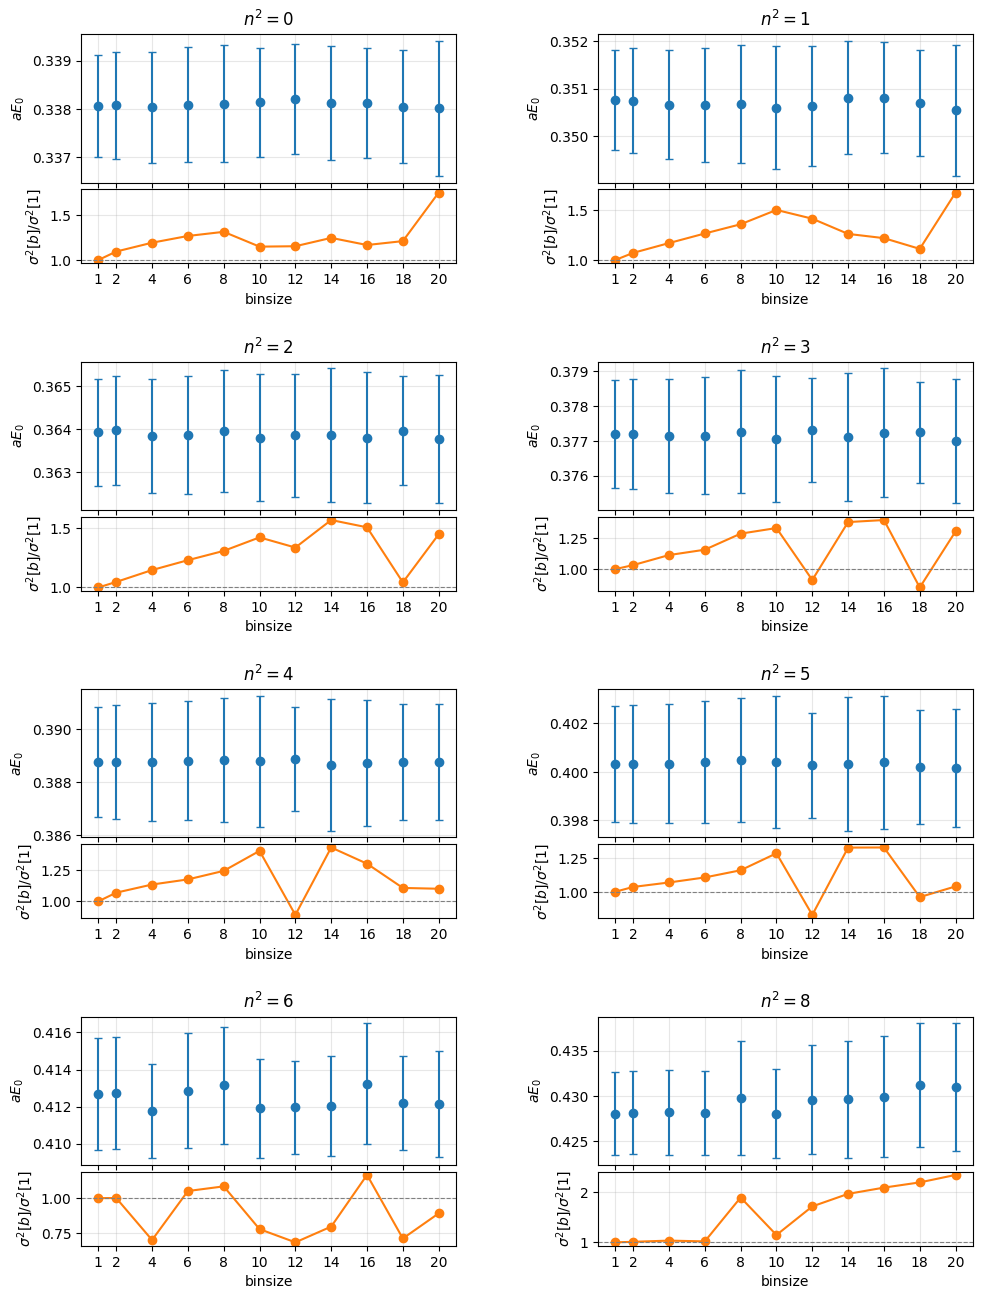

In [50]:
def plot_binsize_energies(results, layout=None, savepath=None):
    """Grid of (E0 vs binsize / variance-ratio vs binsize) pairs, one per nsquare."""
    shells = sorted(results)
    if layout is None:
        layout = [shells[i:i+2] for i in range(0, len(shells), 2)]  # rows of 2

    nrows = len(layout)
    ncols = max(len(r) for r in layout)

    fig = plt.figure(figsize=(5 * ncols, 3.2 * nrows))
    subfigs = np.atleast_2d(fig.subfigures(nrows, ncols, wspace=0.07, hspace=0.10))

    for i, row in enumerate(layout):
        for j in range(ncols):
            sf = subfigs[i, j]
            n = row[j] if j < len(row) else None
            if n is None or n not in results or not results[n]:
                sf.set_visible(False)          # blank cell
                continue

            bins  = sorted(results[n])
            E0    = np.array([results[n][b]["energy"].mean for b in bins])
            err   = np.array([results[n][b]["energy"].sdev for b in bins])
            ratio = (err / err[0])**2          # sigma^2[b] / sigma^2[b=1]

            axa, axb = sf.subplots(
                2, 1, sharex=True,
                gridspec_kw={"height_ratios": [2, 1], "hspace": 0.06},
            )
            axa.errorbar(bins, E0, yerr=err, fmt="o", capsize=3, color="C0")
            axa.set_ylabel(r"$aE_0$")
            axa.set_title(rf"$n^2 = {n}$")
            axa.grid(alpha=0.3)

            axb.plot(bins, ratio, "o-", color="C1")
            axb.axhline(1.0, ls="--", lw=0.8, color="grey")
            axb.set_ylabel(r"$\sigma^2[b]/\sigma^2[1]$")
            axb.set_xlabel("binsize")
            axb.set_xticks(bins)
            axb.grid(alpha=0.3)

    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show()

# default pairing -> [[0,1],[3,4],[5,6],[8]]
plot_binsize_energies(results)